In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", context="notebook")

BASE_DIR = "/content/drive/MyDrive/Cross-Dataset Generalization Thesis"
FEWSHOT_DIR     = os.path.join(BASE_DIR, "few_shot")
FEWSHOT_METRICS = os.path.join(FEWSHOT_DIR, "metrics")
FEWSHOT_NPY     = os.path.join(FEWSHOT_DIR, "npy")

print("Metrics files:", len(os.listdir(FEWSHOT_METRICS)))
print("NPY files:", len(os.listdir(FEWSHOT_NPY)))

Metrics files: 6
NPY files: 12


In [4]:
def load_all_metrics():
    rows = []
    for fname in os.listdir(FEWSHOT_METRICS):
        if not fname.endswith("_metrics.json"):
            continue
        path = os.path.join(FEWSHOT_METRICS, fname)
        with open(path, "r") as f:
            d = json.load(f)

        # infer direction and k from filename
        # fewshot_eurosat_to_ucm_resnet50_k5_metrics.json
        parts = fname.split("_")
        direction = parts[1] + "→" + parts[3]  # "eurosat→ucm" or "ucm→eurosat"
        k_part = parts[-2]                     # "k5"
        k = int(k_part[1:])

        rows.append(
            {
                "direction": direction,
                "source_dataset": d["source_dataset"],
                "target_dataset": d["target_dataset"],
                "model": d["model"],
                "k": k,
                "accuracy": d["accuracy"],
                "macro_f1": d["macro_f1"],
            }
        )
    return pd.DataFrame(rows)

df_all = load_all_metrics().sort_values(["direction", "k"])
df_all

,direction,source_dataset,target_dataset,model,k,accuracy,macro_f1
0,eurosat→ucm,EuroSAT,UC Merced,resnet50,5,0.047619,0.004329
1,eurosat→ucm,EuroSAT,UC Merced,resnet50,10,0.047619,0.004329
2,eurosat→ucm,EuroSAT,UC Merced,resnet50,20,0.047619,0.004329
3,ucm→eurosat,UC Merced,EuroSAT,resnet50,5,0.108333,0.019549
4,ucm→eurosat,UC Merced,EuroSAT,resnet50,10,0.116667,0.020896
5,ucm→eurosat,UC Merced,EuroSAT,resnet50,20,0.116667,0.020896


In [8]:
import os, json

BASE_DIR = "/content/drive/MyDrive/Cross-Dataset Generalization Thesis"
ZERO_METRICS = os.path.join(BASE_DIR, "cross_dataset_zero_shot", "metrics")

def load_zero_summary(direction_label):
    if direction_label == "EuroSAT → UCM":
        fname = "zero_shot_eurosat_to_ucm_summary.json"
    else:
        fname = "zero_shot_ucm_to_eurosat_summary.json"

    path = os.path.join(ZERO_METRICS, fname)
    with open(path, "r") as f:
        data = json.load(f)   # this is a list of dicts

    # find the resnet50_full entry
    resnet_entry = None
    for item in data:
        if item.get("model") == "resnet50_full":
            resnet_entry = item
            break
    if resnet_entry is None:
        raise ValueError(f"resnet50_full not found in {fname}")

    return {
        "Source → Target": direction_label,
        "Model": "ResNet50",
        "Shots per class (k)": 0,
        "Target accuracy": resnet_entry["accuracy"],
        "Target macro-F1": resnet_entry["macro_f1"],
    }


df_fs = load_fewshot()

row_zero_e2u = load_zero_summary("EuroSAT → UCM")
row_zero_u2e = load_zero_summary("UCM → EuroSAT")

In [9]:
# Concatenate zero‑shot and few‑shot rows in the layout of your mockup

df_perf = pd.concat(
    [
        pd.DataFrame([row_zero_e2u]),
        df_fs[df_fs["Source → Target"] == "EuroSAT → UCM"].sort_values("Shots per class (k)"),
        pd.DataFrame([row_zero_u2e]),
        df_fs[df_fs["Source → Target"] == "UCM → EuroSAT"].sort_values("Shots per class (k)"),
    ],
    ignore_index=True,
)

# Pretty label for zero‑shot rows
df_perf.loc[df_perf["Shots per class (k)"] == 0, "Shots per class (k)"] = "0 (zero‑shot)"

print("1. Performance vs shots per class (per direction)")
df_perf

1. Performance vs shots per class (per direction)


/tmp/ipython-input-4243843876.py:14: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0 (zero‑shot)' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_perf.loc[df_perf["Shots per class (k)"] == 0, "Shots per class (k)"] = "0 (zero‑shot)"


,Source → Target,Model,Shots per class (k),Target accuracy,Target macro-F1
0,EuroSAT → UCM,ResNet50,0 (zero‑shot),0.038095,0.003495
1,EuroSAT → UCM,resnet50,5,0.047619,0.004329
2,EuroSAT → UCM,resnet50,10,0.047619,0.004329
3,EuroSAT → UCM,resnet50,20,0.047619,0.004329
4,UCM → EuroSAT,ResNet50,0 (zero‑shot),0.093333,0.017073
5,UCM → EuroSAT,resnet50,5,0.108333,0.019549
6,UCM → EuroSAT,resnet50,10,0.116667,0.020896
7,UCM → EuroSAT,resnet50,20,0.116667,0.020896


In [30]:
# Numeric baselines for gain
zero_acc_e2u = row_zero_e2u["Target accuracy"]
zero_f1_e2u  = row_zero_e2u["Target macro-F1"]
zero_acc_u2e = row_zero_u2e["Target accuracy"]
zero_f1_u2e  = row_zero_u2e["Target macro-F1"]

def build_gain(df_dir, label, zero_acc, zero_f1):
    rows = []
    for _, r in df_dir.iterrows():
        k = int(r["Shots per class (k)"])
        if k == 0:
            continue  # skip zero‑shot row for gain table
        rows.append(
            {
                "Source → Target": label,
                "Model": r["Model"],
                "k": k,
                "Accuracy gain vs zero-shot": r["Target accuracy"] - zero_acc,
                "Macro-F1 gain vs zero-shot": r["Target macro-F1"] - zero_f1,
            }
        )
    return pd.DataFrame(rows)

gain_e2u = build_gain(
    df_fs[df_fs["Source → Target"] == "EuroSAT → UCM"],
    "EuroSAT → UCM",
    zero_acc_e2u,
    zero_f1_e2u,
)
gain_u2e = build_gain(
    df_fs[df_fs["Source → Target"] == "UCM → EuroSAT"],
    "UCM → EuroSAT",
    zero_acc_u2e,
    zero_f1_u2e,
)

df_gain = pd.concat([gain_e2u, gain_u2e], ignore_index=True)

print("2. Few‑shot gain table (per direction)")
df_gain

2. Few‑shot gain table (per direction)


,Source → Target,Model,k,Accuracy gain vs zero-shot,Macro-F1 gain vs zero-shot
0,EuroSAT → UCM,resnet50,5,0.009524,0.000834
1,EuroSAT → UCM,resnet50,10,0.009524,0.000834
2,EuroSAT → UCM,resnet50,20,0.009524,0.000834
3,UCM → EuroSAT,resnet50,5,0.015000,0.002476
4,UCM → EuroSAT,resnet50,10,0.023333,0.003822
5,UCM → EuroSAT,resnet50,20,0.023333,0.003822


### Target Accuracy vs. Shots per Class

These plots visualize the target accuracy as the number of shots per class (k) increases, allowing for a comparison between zero-shot performance and few-shot performance for each transfer direction.

In [22]:
# Add a numerical 'k' column for plotting purposes
plot_perf = df_perf.copy()
plot_perf["k_num"] = plot_perf["Shots per class (k)"].replace({"0 (zero‑shot)": 0}).astype(int)

# Separate data for each transfer direction
perf_e2u = plot_perf[plot_perf["Source → Target"] == "EuroSAT → UCM"].copy()
perf_u2e = plot_perf[plot_perf["Source → Target"] == "UCM → EuroSAT"].copy()

/tmp/ipython-input-1723846395.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  plot_perf["k_num"] = plot_perf["Shots per class (k)"].replace({"0 (zero‑shot)": 0}).astype(int)


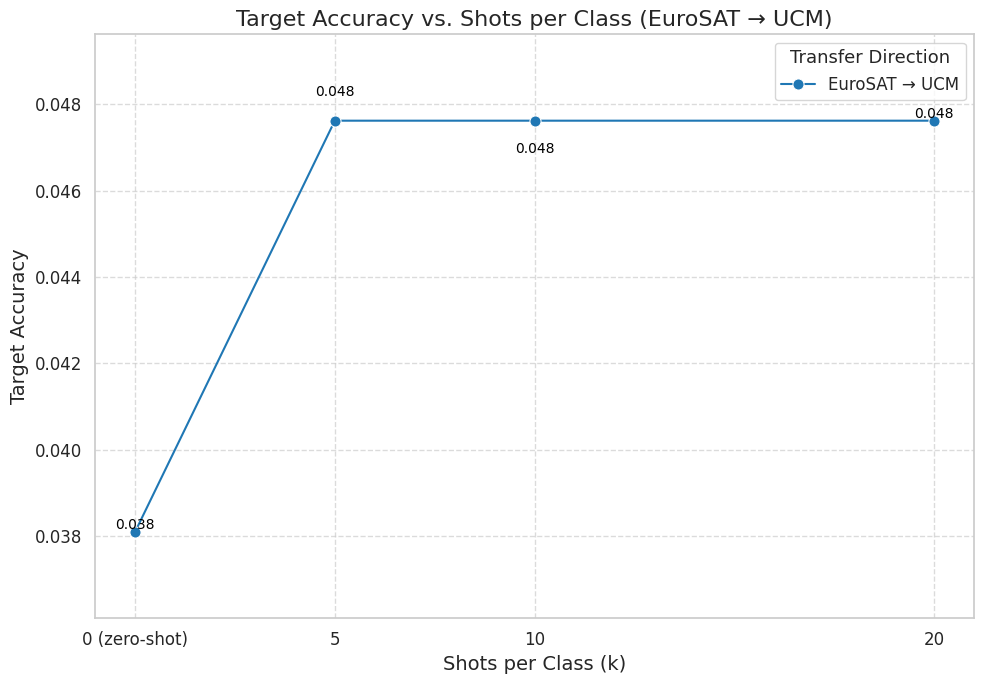

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot for EuroSAT → UCM direction
plt.figure(figsize=(10, 7))
sns.lineplot(
    data=perf_e2u,
    x="k_num",
    y="Target accuracy",
    marker="o",
    markersize=8,
    color="tab:blue",
    label="EuroSAT → UCM"
)

# Add markers for each point with adjusted positions for overlapping labels
y_offset_e2u = {
    0: 0,         # Default position for k=0
    5: 0.0005,    # Slightly above for k=5
    10: -0.0005,   # Slightly below for k=10
    20: 0         # Default position for k=20
}

for index, row in perf_e2u.iterrows():
    offset = y_offset_e2u.get(row['k_num'], 0)
    plt.text(row['k_num'], row['Target accuracy'] + offset, f"{row['Target accuracy']:.3f}",
             ha='center', va='bottom' if offset >=0 else 'top', fontsize=10, color='black') # Adjust va based on offset

plt.title("Target Accuracy vs. Shots per Class (EuroSAT → UCM)", fontsize=16)
plt.xlabel("Shots per Class (k)", fontsize=14)
plt.ylabel("Target Accuracy", fontsize=14)
plt.xticks(perf_e2u["k_num"].unique(), labels=perf_e2u["Shots per class (k)"].unique(), fontsize=12)  # Use original labels for ticks
plt.yticks(fontsize=12)
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend(title="Transfer Direction", title_fontsize='13', fontsize='12')
# Adjust y-axis limits to accommodate labels
min_val_e2u = perf_e2u["Target accuracy"].min()
max_val_e2u = perf_e2u["Target accuracy"].max()
plt.ylim(bottom=max(0, min_val_e2u - 0.002), top=max_val_e2u + 0.002) # Ensure y-axis starts at 0 or slightly below min value, and leaves space at top for labels
plt.tight_layout()
plt.show()

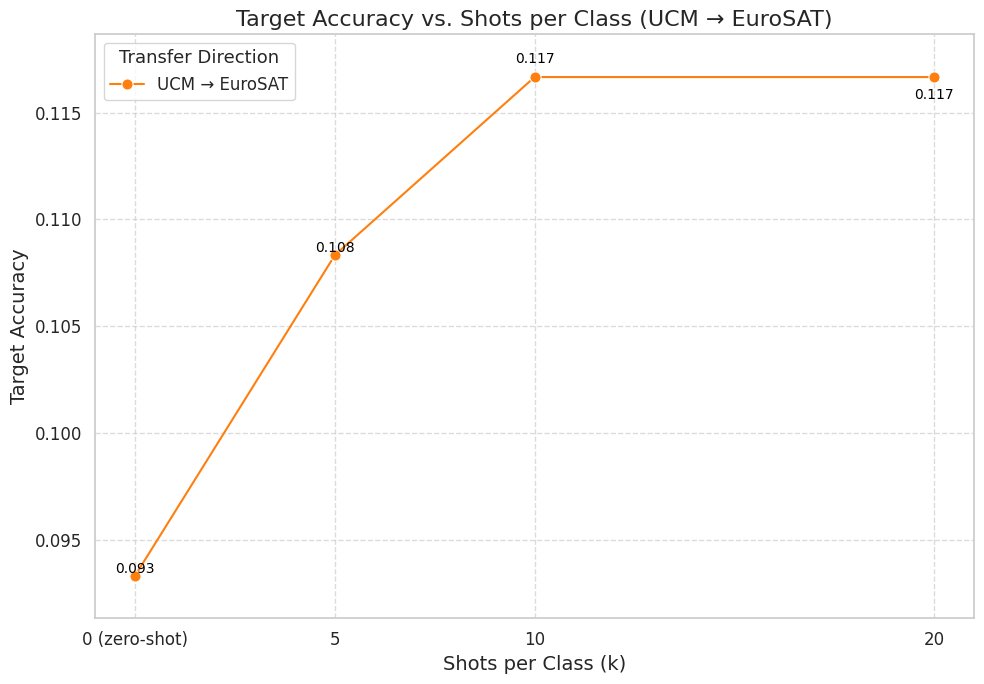

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot for UCM → EuroSAT direction
plt.figure(figsize=(10, 7))
sns.lineplot(
    data=perf_u2e,
    x="k_num",
    y="Target accuracy",
    marker="o",
    markersize=8,
    color="tab:orange",
    label="UCM → EuroSAT"
)

# Add markers for each point with adjusted positions for overlapping labels
y_offset_u2e = {
    0: 0,         # Default position for k=0
    5: 0,         # Default position for k=5
    10: 0.0005,    # Slightly above for k=10
    20: -0.0005   # Slightly below for k=20
}

for index, row in perf_u2e.iterrows():
    offset = y_offset_u2e.get(row['k_num'], 0)
    plt.text(row['k_num'], row['Target accuracy'] + offset, f"{row['Target accuracy']:.3f}",
             ha='center', va='bottom' if offset >=0 else 'top', fontsize=10, color='black') # Adjust va based on offset

plt.title("Target Accuracy vs. Shots per Class (UCM → EuroSAT)", fontsize=16)
plt.xlabel("Shots per Class (k)", fontsize=14)
plt.ylabel("Target Accuracy", fontsize=14)
plt.xticks(perf_u2e["k_num"].unique(), labels=perf_u2e["Shots per class (k)"].unique(), fontsize=12)  # Use original labels for ticks
plt.yticks(fontsize=12)
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend(title="Transfer Direction", title_fontsize='13', fontsize='12')
# Adjust y-axis limits to accommodate labels
min_val_u2e = perf_u2e["Target accuracy"].min()
max_val_u2e = perf_u2e["Target accuracy"].max()
plt.ylim(bottom=max(0, min_val_u2e - 0.002), top=max_val_u2e + 0.002) # Ensure y-axis starts at 0 or slightly below min value, and leaves space at top for labels
plt.tight_layout()
plt.show()